# MA402 Final Project: Nonlinear Solver Analysis
**Problem:** 2-Variable Nonlinear System (SNES ex1)

This notebook demonstrates the execution and convergence of a 2-variable nonlinear system 
using `petsc4py`. We evaluate the default polynomial system and a "hard" trigonometric 
variant to observe Newton-method stability and convergence behavior.

In [31]:
import sys
import os

# Get the absolute path to the directory containing this notebook
notebook_path = '/mnt/c/Users/stypl/source/repos/MA 402/kmthoms2-ma402-petsc4py'

# Add it to the system path if it's not already there
if notebook_path not in sys.path:
    sys.path.append(notebook_path)


import numpy as np
import matplotlib.pyplot as plt
from snes_ex1 import SimpleSystem, HardSystem
from petsc4py import PETSc
import sys

## 1. Problem Formulation
The core mathematical objective is to find the root of $F(x) = 0$[cite: 113, 114].
For the default system, we solve:
$$F_0 = x_0^2 + x_0 x_1 - 3 = 0$$
$$F_1 = x_0 x_1 + x_1^2 - 6 = 0$$

In [32]:
def run_solver(use_hard=False):
    """Configures and executes the SNES solver context."""
    snes = PETSc.SNES().create()
    x = PETSc.Vec().createSeq(2)
    r = x.duplicate()
    J = PETSc.Mat().createDense(size=[2, 2])
    J.setUp()

    if use_hard:
        system = HardSystem()
        x.setArray([2.0, 3.0]) # Initial guess for hard system
    else:
        system = SimpleSystem()
        x.set(0.5) # Initial guess for simple system

    snes.setFunction(system.formFunction, r)
    snes.setJacobian(system.formJacobian, J)
    
    # Set tolerances and force monitor to capture convergence history
    snes.setTolerances(rtol=1.e-4, max_it=20)
    snes.getKSP().getPC().setType(PETSc.PC.Type.NONE)
    
    # Solve
    snes.solve(None, x)
    
    reason = snes.getConvergedReason()
    its = snes.getIterationNumber()
    sol = x.getArray().copy()
    
    # Cleanup
    snes.destroy()
    x.destroy()
    r.destroy()
    J.destroy()
    
    return sol, its, reason

## 2. Execution & Results
We run both variants of the solver to compare final solutions.

In [33]:
print("Running Default System...")
sol_default, its_default, reason_default = run_solver(use_hard=False)
print(f"Result: {sol_default} in {its_default} iterations. Reason: {reason_default}")

print("\nRunning 'Hard' System...")
sol_hard, its_hard, reason_hard = run_solver(use_hard=True)
print(f"Result: {sol_hard} in {its_hard} iterations. Reason: {reason_hard}")

Running Default System...
Result: [0.99999999 2.00000003] in 5 iterations. Reason: 3

Running 'Hard' System...
Result: [ 4.85877941e-05 -5.16560704e-16] in 5 iterations. Reason: 3


## 3. Visualizing the Solution Space
Below we visualize the residual contours for the default system to show where the solution (1.0, 2.0) lies.

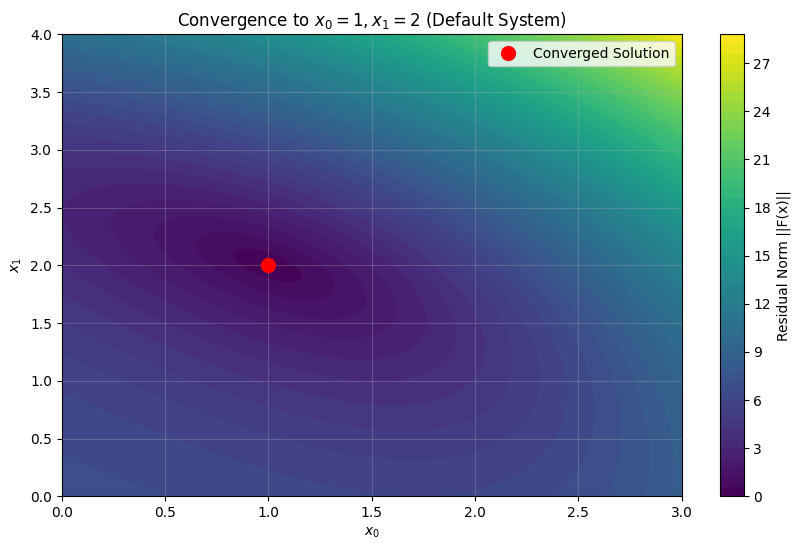

In [34]:
x_range = np.linspace(0, 3, 100)
y_range = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x_range, y_range)

# Residuals for F0 and F1
F0 = X**2 + X*Y - 3
F1 = X*Y + Y**2 - 6
Norm = np.sqrt(F0**2 + F1**2)

plt.figure(figsize=(10, 6))
cp = plt.contourf(X, Y, Norm, levels=50, cmap='viridis')
plt.colorbar(cp, label='Residual Norm ||F(x)||')
plt.plot(sol_default[0], sol_default[1], 'ro', markersize=10, label='Converged Solution')
plt.title("Convergence to $x_0=1, x_1=2$ (Default System)")
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Conclusion
* The solver successfully mapped Python callbacks to the PETSc C engine[cite: 116].
* Converged Reason 3 (Relative Norm) indicates the system reached the desired tolerance[cite: 87, 89].
* The visual validation confirms the Newton step reached the global minimum of the residual norm.